### ARBOUET - CEMES-CNRS - 2026
### test program for opimization using pytorch
### context : amplitude and phase shaping for electron beam shaping - active compensation of TEM aberrations

Tensor shape: torch.Size([1080, 1920])
dtype: torch.float32
Tensor shape: torch.Size([1080, 1920])
dtype: torch.float32
tensor(0.9961)


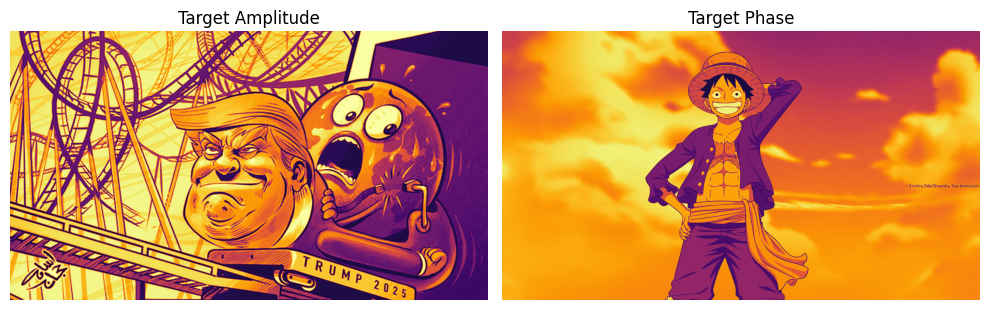

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from PIL import Image
import torch
from torchvision import transforms
import torch.nn.functional as F

def image_to_tensor(filename, nx, ny):
    img = Image.open(filename).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((ny, nx)), 
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(), ])
    img_tensor = transform(img).squeeze(0)
    print("Tensor shape:", img_tensor.shape)
    print("dtype:", img_tensor.dtype)
    return img_tensor

def gaussian_spot(shape, center, sigma):
    """
    Create a Gaussian spot centered at `center` with standard deviation `sigma` in a tensor of given `shape`.
    
    Args:
    - shape (tuple): The shape of the output tensor (Npix, Npix).
    - center (tuple): The coordinates of the center of the Gaussian spot (i0, j0).
    - sigma (float): The standard deviation of the Gaussian spot.
    
    Returns:
    - torch.Tensor: A tensor with a Gaussian spot.
    """
    Npix_x, Npix_y = shape
    i0, j0 = center
    x = torch.arange(Npix_x).float()
    y = torch.arange(Npix_y).float()
    X, Y = torch.meshgrid(x, y, indexing='ij')
    gauss = torch.exp(-((X - i0) ** 2 + (Y - j0) ** 2) / (2 * sigma ** 2))
    return gauss

def gaussian_kernel_2d(kernel_size, sigma, device="cpu"):
    ax = torch.arange(kernel_size, device=device) - kernel_size // 2
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel

def display_2_images(image_1, image_2, title_1, title_2  ):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    im = axs[0].imshow(image_1, cmap = 'inferno')
    axs[0].set_title(title_1)
    axs[0].axis("off")
   # plt.colorbar(im)
    im2 = axs[1].imshow(image_2, cmap = 'inferno')
    axs[1].set_title(title_2)
    axs[1].axis("off")
    #plt.colorbar(im2)

    plt.tight_layout()
    plt.show()

def gaussian_blur_real(img, sigma):
    """
    img: torch.Tensor (H, W) or (B, C, H, W)
    sigma: standard deviation in pixels
    """
    if img.ndim == 2:
        img = img[None, None]   # (1,1,H,W)

    kernel_size = int(6 * sigma + 1)
    if kernel_size % 2 == 0:
        kernel_size += 1

    kernel = gaussian_kernel_2d(kernel_size, sigma, device=img.device)
    kernel = kernel[None, None]

    return F.conv2d(img, kernel, padding=kernel_size//2).squeeze()

def gaussian_blur_complex(field, sigma):
    real = gaussian_blur_real(field.real, sigma)
    imag = gaussian_blur_real(field.imag, sigma)
    return real + 1j * imag


def square_mask(shape, X0, Y0, SX, SY, dtype=torch.float32):
    """
    shape: (H, W)
    X0, Y0: center (column, row)
    S: lateral size of the square (pixels)
    """
    H, W = shape
    halfX = SX // 2
    halfY = SY // 2
    y = torch.arange(H).view(-1, 1)
    x = torch.arange(W).view(1, -1)
    mask = ((torch.abs(x - X0) <= halfX) & (torch.abs(y - Y0) <= halfY) )
    return mask.to(dtype)


N_slm_x = 1920
N_slm_y = 1080

directory = r'C:\Users\weber\Labo\ProgrammesPython\PyMoDAQ_Git\pymodaq_plugins_folder\pymodaq_plugins_optical_2D_shaping_private\src\pymodaq_plugins_optical_2D_shaping/resources/'
file_amplitude = 'osama.png'
file_phase = 'one_piece.png'
image_amplitude = image_to_tensor(directory+file_amplitude, N_slm_x, N_slm_y)
image_phase = image_to_tensor(directory+file_phase, N_slm_x, N_slm_y)
image_phase * torch.pi / torch.max(image_phase)

print(image_phase.max())

display_2_images(image_amplitude, image_phase, "Target Amplitude", "Target Phase") 


Starting Optimization loop

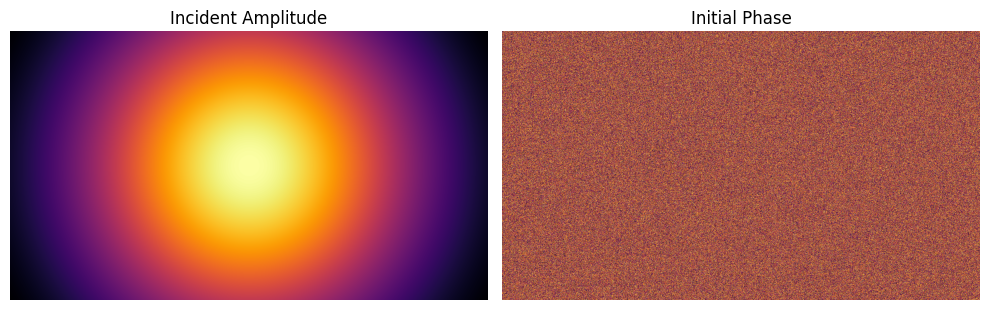

In [23]:
phase_ini  = torch.rand(N_slm_y, N_slm_x)*2*torch.pi
amplitude_inc = gaussian_spot((N_slm_y,N_slm_x),(N_slm_y // 2, N_slm_x // 2), 500)
#amplitude_inc = torch.ones(N_slm_y, N_slm_x)

display_2_images(amplitude_inc, phase_ini, "Incident Amplitude", "Initial Phase")

image_amplitude  = image_amplitude / image_amplitude.max()
target_amplitude = image_amplitude.clone().detach().requires_grad_(True)

phase = phase_ini.clone().detach().requires_grad_(True)
#phase = phase_60
cplx_target = image_amplitude * torch.exp(1j * image_phase)
target_cplx_amplitude = cplx_target.clone().detach().requires_grad_(True)

shape = (N_slm_x, N_slm_y)

# Choosing size and center of "shaped" region
sizeX = 0.6 * N_slm_x
sizeY = 0.6 * N_slm_y
X0 = int(0.5 * N_slm_x )
Y0 = int(0.5 * N_slm_y )

mask = square_mask((N_slm_y, N_slm_x), X0=X0, Y0=Y0, SX=sizeX, SY=sizeY)

## Optimization with LBFGS algorithm 
### original version without optimization of intensity in "shaped" region

In [24]:
n_iter = 41                             # Number of optimization loops

optimizer = torch.optim.LBFGS(
    [phase],
    lr=1.0,
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe"
)
#mask_out = 1.0 - mask
# Subsample factor
#k = 100
#target_cplx_amplitude_out = target_cplx_amplitude * mask_out

#target_cplx_amplitude_out = target_cplx_amplitude_out.unsqueeze(0).unsqueeze(0)
#target_cplx_amplitude_out_blur = F.avg_pool2d(torch.real(target_cplx_amplitude_out), kernel_size=k, stride=k) + 1j * F.avg_pool2d(torch.imag(target_cplx_amplitude_out), kernel_size=k, stride=k)
#target_cplx_amplitude_out_blur = gaussian_blur_complex(target_cplx_amplitude_out, sigma=2.0)
#target_cplx_amplitude_out_blur = target_cplx_amplitude_out_blur.squeeze()
#target_cplx_amplitude_out_sub = target_cplx_amplitude_out_blur[::k, ::k]

target_cplx_amplitude = target_cplx_amplitude.detach()
#target_cplx_amplitude_out_sub = target_cplx_amplitude_out_sub.detach()
#target_intensity_out = torch.abs(target_cplx_amplitude_out_sub)**2

#mask = mask.detach().float()
#mask_out = mask_out.detach().float()
#weight_out = torch.sum(mask_out)
#weight_in = torch.sum(mask)

amplitude_inc = amplitude_inc.detach()

In [25]:
amplitude_inc.requires_grad

False

In [27]:

for it in range(n_iter):
    def closure():
        optimizer.zero_grad()

        field = amplitude_inc * torch.exp(1j * phase)
        focal_field = torch.fft.fftshift(torch.fft.fft2(field))

        #diff_phase = torch.angle(focal_field) - image_phase
        #weight_loss = torch.ones(N_slm_y, N_slm_x)
        #threshold = diff_phase.max() * loss_boost_fraction
        #mask = diff_phase.abs() >= threshold
        #weight_loss = torch.ones_like(diff_phase)
        #weight_loss[mask] = loss_boost
        focal_field / torch.abs(focal_field).detach().max()
        diff_in = (focal_field - target_cplx_amplitude) * mask
     #   diff_out = (torch.abs(focal_field) - mask)

      #  focal_field_out = focal_field * mask_out
      #  focal_field_out = focal_field_out.unsqueeze(0).unsqueeze(0)
      #  focal_field_out_blur = F.avg_pool2d(torch.real(focal_field_out), kernel_size=k, stride=k) + 1j * F.avg_pool2d(torch.imag(focal_field_out), kernel_size=k, stride=k)
      #  focal_field_out_blur = focal_field_out_blur.squeeze()
      #  focal_field_out_blur = gaussian_blur_complex(focal_field_out, sigma=2.0)
      #  focal_field_out_sub = focal_field_out_blur[::k, ::k]
      #  intensity_out = torch.abs(focal_field_out_sub)**2
      #  intensity_out = intensity_out / intensity_out.detach().max()
      #  alpha =  min(1.0, it / (1 * n_iter))
        loss_field = torch.mean(torch.abs(diff_in)**2)
      #  I = torch.abs(focal_field)**2
      #  energy_in  = torch.sum(I * mask)
      #  energy_tot = torch.sum(I)
      #  loss_energy = 1.0 - energy_in / (energy_tot + 1e-12)
        loss = loss_field #+ alpha * loss_energy
        loss.backward()
        return loss

    loss = optimizer.step(closure)

    if it % 5 == 0:
        print(f"Iteration {it:4d} | Loss = {loss.item():.4e}")


Iteration    0 | Loss = 2.4549e+05
Iteration    5 | Loss = 3.7945e-01
Iteration   10 | Loss = 6.5059e-03


KeyboardInterrupt: 

tensor(19.7977, grad_fn=<MaxBackward1>)

In [30]:

field = amplitude_inc * torch.exp(1j * phase)
focal_field = torch.fft.fftshift(torch.fft.fft2(field))
output_amplitude = torch.abs(focal_field)
output_phase = torch.angle(focal_field)

print('')
print('Ratio of intensity IN/OUT')
int_in = torch.sum((output_amplitude * mask)**2)
int_out = torch.sum((output_amplitude * (1 - mask))**2)
print(100 * int_in / int_out,' %')



Ratio of intensity IN/OUT
tensor(2.2577e-05, grad_fn=<DivBackward0>)  %


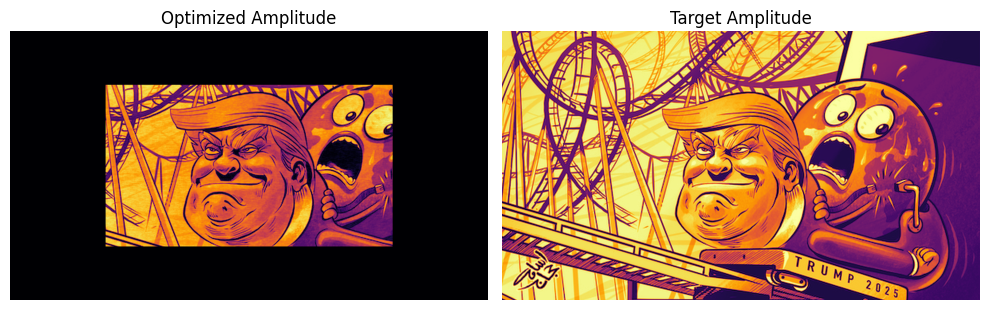

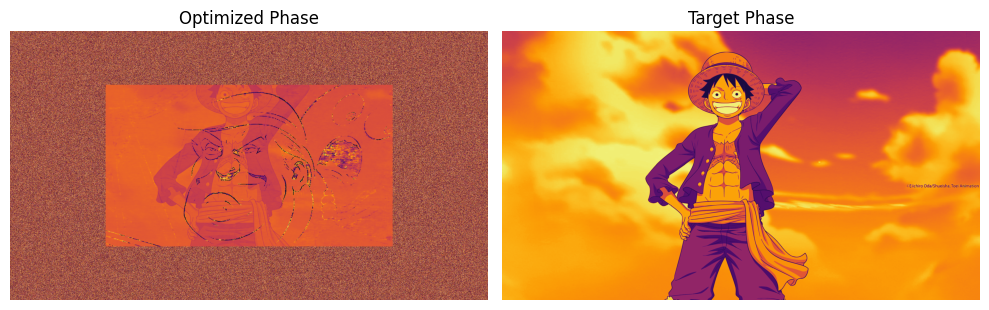

In [31]:
display_2_images((output_amplitude * mask ).detach().numpy() , target_amplitude.detach().numpy(), "Optimized Amplitude", "Target Amplitude") 
display_2_images(output_phase.detach().numpy(),image_phase.detach().numpy(), "Optimized Phase", "Target Phase") 

## Optimization with LBFGS algorithm 
### Tentative optimization of intensity in shaped region

In [ ]:
n_iter = 101                             # Number of optimization loops
loss_boost = 1.0
loss_boost_fraction = 1.0

optimizer = torch.optim.LBFGS(
    [phase],
    lr=1.0,
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe"
)
mask_out = 1.0 - mask
# Subsample factor
k = 100
target_cplx_amplitude_out = target_cplx_amplitude * mask_out

target_cplx_amplitude_out = target_cplx_amplitude_out.unsqueeze(0).unsqueeze(0)
target_cplx_amplitude_out_blur = F.avg_pool2d(torch.real(target_cplx_amplitude_out), kernel_size=k, stride=k) + 1j * F.avg_pool2d(torch.imag(target_cplx_amplitude_out), kernel_size=k, stride=k)
#target_cplx_amplitude_out_blur = gaussian_blur_complex(target_cplx_amplitude_out, sigma=2.0)
target_cplx_amplitude_out_blur = target_cplx_amplitude_out_blur.squeeze()
target_cplx_amplitude_out_sub = target_cplx_amplitude_out_blur[::k, ::k]

target_cplx_amplitude = target_cplx_amplitude.detach()
target_cplx_amplitude_out_sub = target_cplx_amplitude_out_sub.detach()
target_intensity_out = torch.abs(target_cplx_amplitude_out_sub)**2

mask = mask.detach().float()
mask_out = mask_out.detach().float()
weight_out = torch.sum(mask_out)
weight_in = torch.sum(mask)

amplitude_inc = amplitude_inc.detach()

for it in range(n_iter):
    def closure():
        optimizer.zero_grad()

        field = amplitude_inc * torch.exp(1j * phase)
        focal_field = torch.fft.fftshift(torch.fft.fft2(field))

        #diff_phase = torch.angle(focal_field) - image_phase
        #weight_loss = torch.ones(N_slm_y, N_slm_x)
        #threshold = diff_phase.max() * loss_boost_fraction
        #mask = diff_phase.abs() >= threshold
        #weight_loss = torch.ones_like(diff_phase)
        #weight_loss[mask] = loss_boost
        focal_field / torch.abs(focal_field).detach().max()
        diff_in = (focal_field - target_cplx_amplitude) * mask 
        diff_out = (torch.abs(focal_field) - mask)

      #  focal_field_out = focal_field * mask_out
      #  focal_field_out = focal_field_out.unsqueeze(0).unsqueeze(0)
      #  focal_field_out_blur = F.avg_pool2d(torch.real(focal_field_out), kernel_size=k, stride=k) + 1j * F.avg_pool2d(torch.imag(focal_field_out), kernel_size=k, stride=k)
      #  focal_field_out_blur = focal_field_out_blur.squeeze()
      #  focal_field_out_blur = gaussian_blur_complex(focal_field_out, sigma=2.0)
      #  focal_field_out_sub = focal_field_out_blur[::k, ::k]
      #  intensity_out = torch.abs(focal_field_out_sub)**2
      #  intensity_out = intensity_out / intensity_out.detach().max()
        alpha =  min(1.0, it / (1 * n_iter))
        loss_field = torch.mean(torch.abs(diff_in)**2)
        I = torch.abs(focal_field)**2
        energy_in  = torch.sum(I * mask)
        energy_tot = torch.sum(I)
        loss_energy = 1.0 - energy_in / (energy_tot + 1e-12)
        loss = loss_field + alpha * loss_energy
        loss.backward()
        return loss
    
    loss = optimizer.step(closure)

    if it % 5 == 0:
        print(f"Iteration {it:4d} | Loss = {loss.item():.4e}")    

field = amplitude_inc * torch.exp(1j * phase)
focal_field = torch.fft.fftshift(torch.fft.fft2(field))
output_amplitude = torch.abs(focal_field)
output_phase = torch.angle(focal_field)

print('')
print('Ratio of intensity IN/OUT')
int_in = torch.sum((output_amplitude * mask)**2)
int_out = torch.sum((output_amplitude * (1 - mask))**2)
print(100 * int_in / int_out,' %')


Iteration    0 | Loss = 1.1112e+05
Iteration    5 | Loss = 7.1900e+00
Iteration   10 | Loss = 1.7358e+00
Iteration   15 | Loss = 8.8120e-01
Iteration   20 | Loss = 6.0822e-01
Iteration   25 | Loss = 5.1420e-01
Iteration   30 | Loss = 4.8609e-01
Iteration   35 | Loss = 4.9198e-01
Iteration   40 | Loss = 5.1354e-01
Iteration   45 | Loss = 5.4405e-01
Iteration   50 | Loss = 5.7975e-01
Iteration   55 | Loss = 6.1806e-01
Iteration   60 | Loss = 6.5783e-01
Iteration   65 | Loss = 6.9987e-01
Iteration   70 | Loss = 7.4307e-01
Iteration   75 | Loss = 7.8772e-01
Iteration   80 | Loss = 8.3348e-01
Iteration   85 | Loss = 8.7981e-01
Iteration   90 | Loss = 9.2662e-01
Iteration   95 | Loss = 9.7377e-01
Iteration  100 | Loss = 1.0212e+00

Ratio of intensity IN/OUT
tensor(0.0001, grad_fn=<DivBackward0>)  %


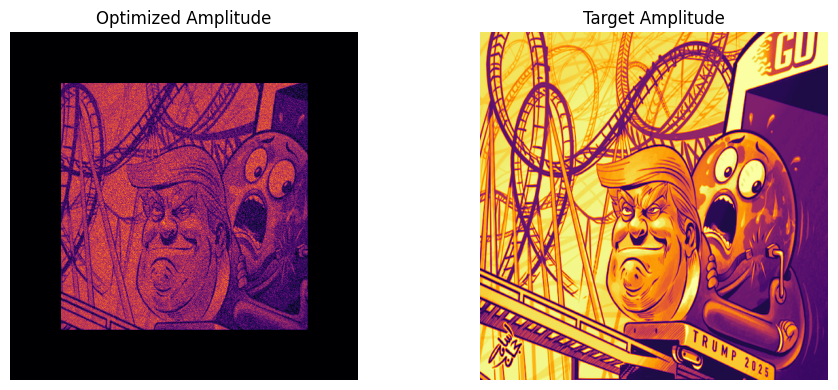

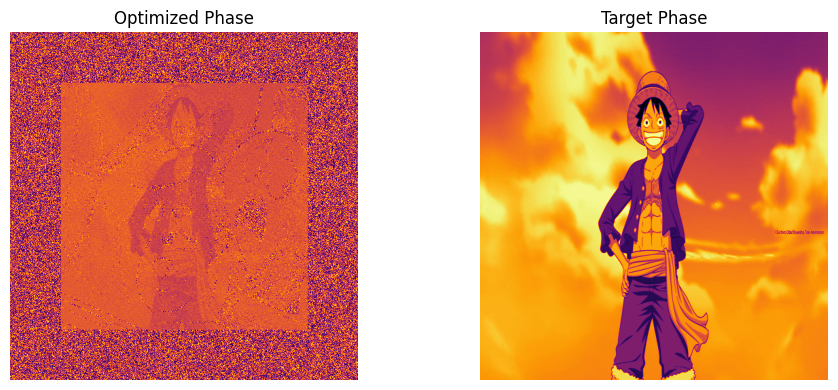

In [443]:
display_2_images((output_amplitude * mask ).detach().numpy() , target_amplitude.detach().numpy(), "Optimized Amplitude", "Target Amplitude") 
display_2_images(output_phase.detach().numpy(),image_phase.detach().numpy(), "Optimized Phase", "Target Phase") 

## Optimization with ADAM algorithm 

Iteration    0 | Loss = 2.6102e+19
Iteration   50 | Loss = 2.4137e+19
Iteration  100 | Loss = 2.2209e+19
Iteration  150 | Loss = 2.0317e+19
Iteration  200 | Loss = 1.8468e+19
Iteration  250 | Loss = 1.6674e+19
Iteration  300 | Loss = 1.4946e+19
Iteration  350 | Loss = 1.3299e+19
Iteration  400 | Loss = 1.1744e+19
Iteration  450 | Loss = 1.0292e+19
Iteration  500 | Loss = 8.9507e+18
Iteration  550 | Loss = 7.7261e+18
Iteration  600 | Loss = 6.6201e+18
Iteration  650 | Loss = 5.6324e+18
Iteration  700 | Loss = 4.7597e+18
Iteration  750 | Loss = 3.9967e+18
Iteration  800 | Loss = 3.3359e+18
Iteration  850 | Loss = 2.7689e+18
Iteration  900 | Loss = 2.2862e+18
Iteration  950 | Loss = 1.8782e+18
Iteration 1000 | Loss = 1.5354e+18
Iteration 1050 | Loss = 1.2489e+18
Iteration 1100 | Loss = 1.0103e+18
Iteration 1150 | Loss = 8.1245e+17
Iteration 1200 | Loss = 6.4892e+17
Iteration 1250 | Loss = 5.1422e+17
Iteration 1300 | Loss = 4.0370e+17
Iteration 1350 | Loss = 3.1346e+17
Iteration 1400 | Los

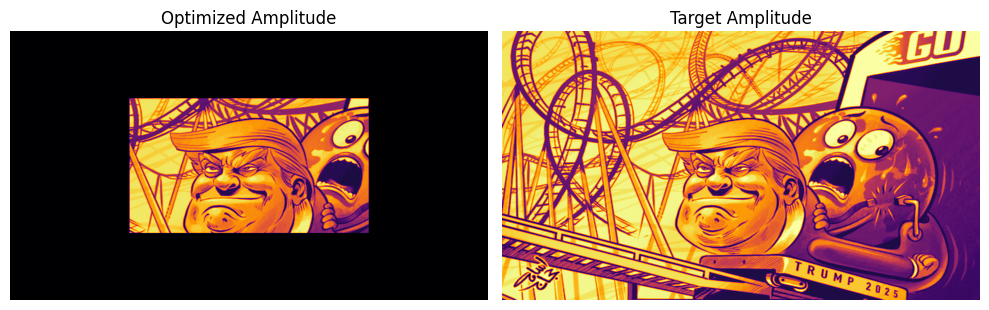

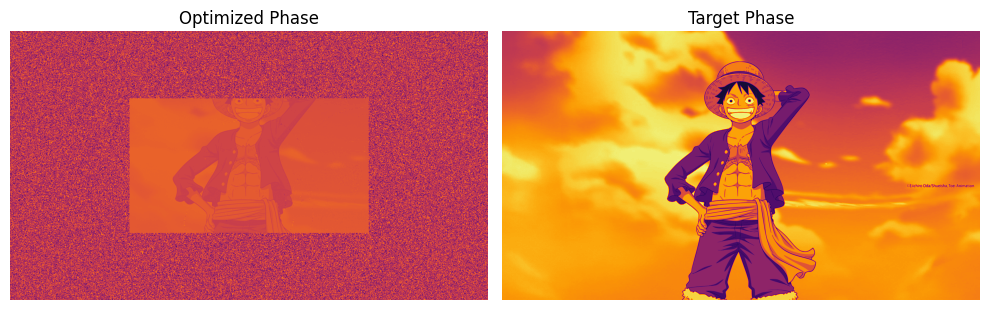

In [158]:
n_iter = 5001                             # Number of optimization loops

optimizer = optim.Adam([phase], lr=0.001) # optimizer

for it in range(n_iter):
    optimizer.zero_grad()
    field = torch.exp(1j * phase) * amplitude_inc
    focal_field = torch.fft.fftshift(torch.fft.fft2(field))

    intensity    = torch.abs(focal_field) ** 2
    phase_output = torch.angle(focal_field)
    # intensity = intensity / intensity.detach().max()
    # Loss function for amplitude and phase
    loss = 10**9 * torch.sum(torch.abs(focal_field * mask - target_cplx_amplitude * mask)**1.5 )
   # Loss function for intensity only - lr = 0.001 - 5000 iterations OK
   # loss = torch.mean((torch.sqrt(intensity + 1e-8) -
   #                torch.sqrt(target_intensity + 1e-8)) ** 2)
    loss.backward()
    optimizer.step()

    if it % 50 == 0:
        print(f"Iteration {it:4d} | Loss = {loss.item():.4e}")

output_amplitude = torch.abs(focal_field)
output_phase = torch.angle(focal_field)

display_2_images((output_amplitude * mask).detach().numpy() , target_amplitude.detach().numpy(), "Optimized Amplitude", "Target Amplitude") 
display_2_images(output_phase.detach().numpy(),image_phase.detach().numpy(), "Optimized Phase", "Target Phase") 

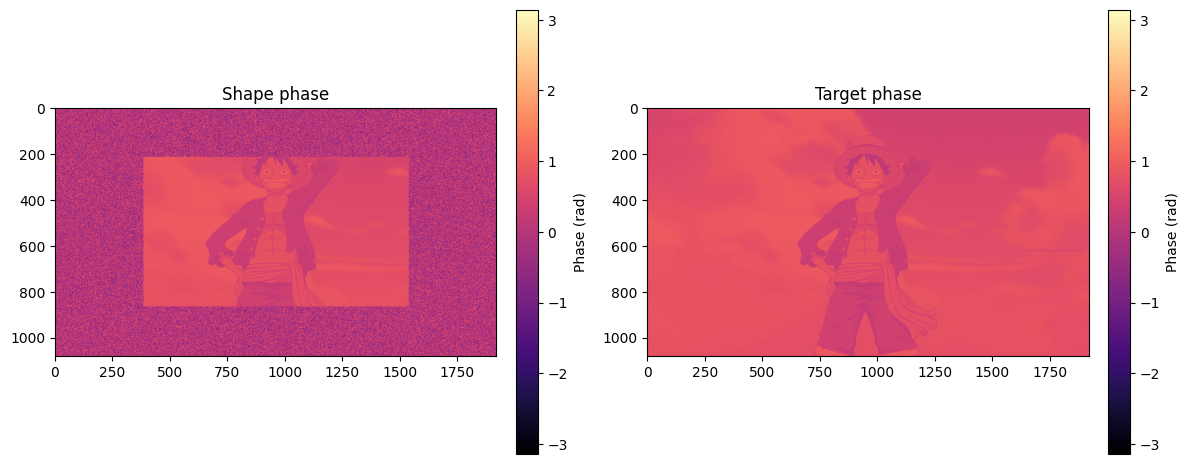

In [22]:
fig, ax = plt.subplots(1,2,figsize=(12, 6))
ax[0].set_title('Shape phase')
im =ax[0].imshow(output_phase.detach().numpy(), vmin = -np.pi, vmax = np.pi, cmap = 'magma') 
cbar = plt.colorbar(im, ax = ax[0], fraction=0.046, pad=0.04)
cbar.set_label("Phase (rad)")
ax[1].set_title('Target phase')
im = ax[1].imshow(image_phase.detach().numpy(), vmin = -np.pi, vmax = np.pi, cmap = 'magma') 
cbar2 = plt.colorbar(im, ax = ax[1], fraction=0.046, pad=0.04)
cbar2.set_label("Phase (rad)")
plt.tight_layout()

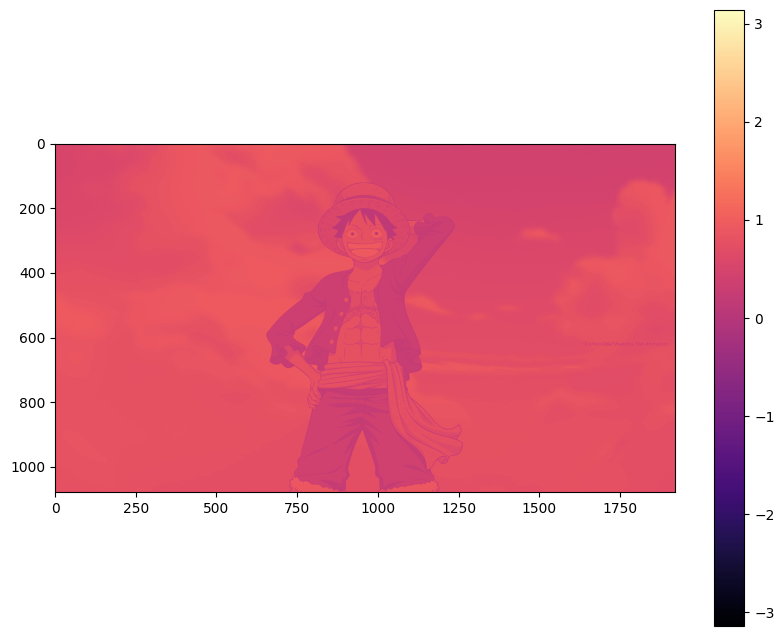

In [148]:
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(image_phase.detach().numpy(), vmin = -np.pi, vmax = np.pi, cmap = 'magma') 
plt.colorbar(im, ax = ax)